STEP 1

In [1]:
#============================================================
# 1 — Import libraries
# ============================================================
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, SelectMultiple, Dropdown


# ============================================================
# 2 — Load raw dataset
# ============================================================
file_path = "resources/public-transport-crime-london.xlsx"
raw_df = pd.read_excel(file_path, sheet_name="Volume and Rates", header=None)


STEP 2

In [2]:
# ============================================================
# 3 — Identify mode rows and FY header rows
# ============================================================
modes = [
    "Bus", "London Underground", "Docklands Light Railway",
    "London Underground / Docklands Light Railway",
    "London Overground", "London Tramlink", "Trams",
    "TfL Rail", "Elizabeth Line", "All transport modes"
]

mode_rows = raw_df[raw_df.apply(lambda row: row.astype(str).str.contains("|".join(modes)).any(), axis=1)]
fy_rows = raw_df[raw_df.apply(lambda row: row.astype(str).str.contains("Network-wide FY").any(), axis=1)]

fy_indices = fy_rows.index.tolist()
fy_indices.append(len(raw_df))


# ============================================================
# 4 — Slice dataset into FY blocks
# ============================================================
blocks = []
for i in range(len(fy_indices) - 1):
    start = fy_indices[i]
    end = fy_indices[i+1]
    blocks.append(raw_df.iloc[start:end])


# ============================================================
# 5 — Helper functions for block → long format
# ============================================================
def extract_financial_year(block):
    header_text = str(block.iloc[0, 0])
    match = re.search(r"FY(\d{4}/\d{2})", header_text)
    return match.group(1) if match else None

def generate_dates(fin_year):
    start_year = int(fin_year[:4])
    return pd.date_range(start=f"{start_year}-04-01", periods=12, freq="MS")

def get_mode_rows(block):
    return block.iloc[2:].dropna(subset=[block.columns[0]])

def split_vol_rate(row):
    values = row.iloc[1:].tolist()
    volumes = values[0::2]
    rates = values[1::2]
    return volumes, rates

def build_mode_rows(mode_name, volumes, rates, dates):
    return [
        {"date": d, "mode": mode_name, "volume": v, "rate": r}
        for d, v, r in zip(dates, volumes, rates)
    ]

def block_to_long(block):
    fin_year = extract_financial_year(block)
    dates = generate_dates(fin_year)
    mode_rows = get_mode_rows(block)

    long_rows = []
    for _, row in mode_rows.iterrows():
        mode_name = row.iloc[0]
        volumes, rates = split_vol_rate(row)
        long_rows.extend(build_mode_rows(mode_name, volumes, rates, dates))

    return pd.DataFrame(long_rows)


# ============================================================
# 6 — Convert all blocks to long format
# ============================================================
long_blocks = [block_to_long(b) for b in blocks]
full_long_df = pd.concat(long_blocks, ignore_index=True)


# ============================================================
# 7 — Clean mode names
# ============================================================
clean_df = full_long_df.copy()

clean_df["mode"] = clean_df["mode"].replace({
    "London Tramlink": "Tram",
    "Trams": "Tram",
    "Tramlink": "Tram",
    "London Trams": "Tram",
    "London Underground / Docklands Light Railway": "LU+DLR",
    "London Underground": "LU",
    "Docklands Light Railway": "DLR",
    "TfL Rail": "TfL Rail",
    "Elizabeth Line (formerly TfL Rail)": "Elizabeth Line"
})


# ============================================================
# 8 — Combine LU + DLR (weighted average)
# ============================================================
separate = clean_df[clean_df["mode"].isin(["LU", "DLR"])]

combined_lu_dlr = (
    separate.groupby("date")
    .apply(lambda g: pd.Series({
        "mode": "LU+DLR",
        "volume": g["volume"].sum(),
        "rate": (g["volume"] * g["rate"]).sum() / g["volume"].sum()
    }), include_groups=False)
    .reset_index()
)

clean_df_no_lu_dlr = clean_df[~clean_df["mode"].isin(["LU", "DLR"])]
clean_df_combined = pd.concat([clean_df_no_lu_dlr, combined_lu_dlr], ignore_index=True)
clean_df_combined = clean_df_combined.sort_values(["date", "mode"]).reset_index(drop=True)


# ============================================================
# 9 — Clean numeric columns
# ===========================================================
clean_df_combined["volume"] = (
    clean_df_combined["volume"].astype(str).str.replace(",", "", regex=False)
)
clean_df_combined["rate"] = (
    clean_df_combined["rate"].astype(str).str.replace(",", "", regex=False)
)

clean_df_combined["volume"] = pd.to_numeric(clean_df_combined["volume"], errors="coerce")
clean_df_combined["rate"] = pd.to_numeric(clean_df_combined["rate"], errors="coerce")


# ============================================================
# 10 — Compute “All transport modes” (weighted)
# ============================================================
grouped = clean_df_combined.groupby("date")

all_modes_rows = []
for date, group in grouped:
    total_volume = group["volume"].sum()
    valid = group.dropna(subset=["rate"])
    weighted_rate = (valid["volume"] * valid["rate"]).sum() / valid["volume"].sum()

    all_modes_rows.append({
        "date": date,
        "mode": "All transport modes",
        "volume": total_volume,
        "rate": weighted_rate
    })

all_modes_df = pd.DataFrame(all_modes_rows)

clean_df_with_all = pd.concat([clean_df_combined, all_modes_df], ignore_index=True)


# ============================================================
# 11 — Final mode name cleanup + renaming columns
# ============================================================
clean_df_with_all["mode"] = clean_df_with_all["mode"].replace({
    "London Tramlink": "Trams",
    "Trams": "Trams",
    "TfL Rail": "Elizabeth Line",
    "London Underground / Docklands Light Railway": "LU+DLR"
})

clean_df_with_all = clean_df_with_all.rename(columns={
    "volume": "journeys_millions",
    "rate": "crime_rate"
})

clean_df_with_all = clean_df_with_all.sort_values(["date", "mode"]).reset_index(drop=True)

STEP 3

interactive(children=(SelectMultiple(description='Modes', index=(0,), options=('All transport modes', 'Bus', '…

Saved: crime_rates_All_transport_modes.png
Saved: crime_rates_Bus.png
Saved: crime_rates_Elizabeth_Line.png
Saved: crime_rates_LU+DLR.png
Saved: crime_rates_London_Overground.png
Saved: crime_rates_Tram.png


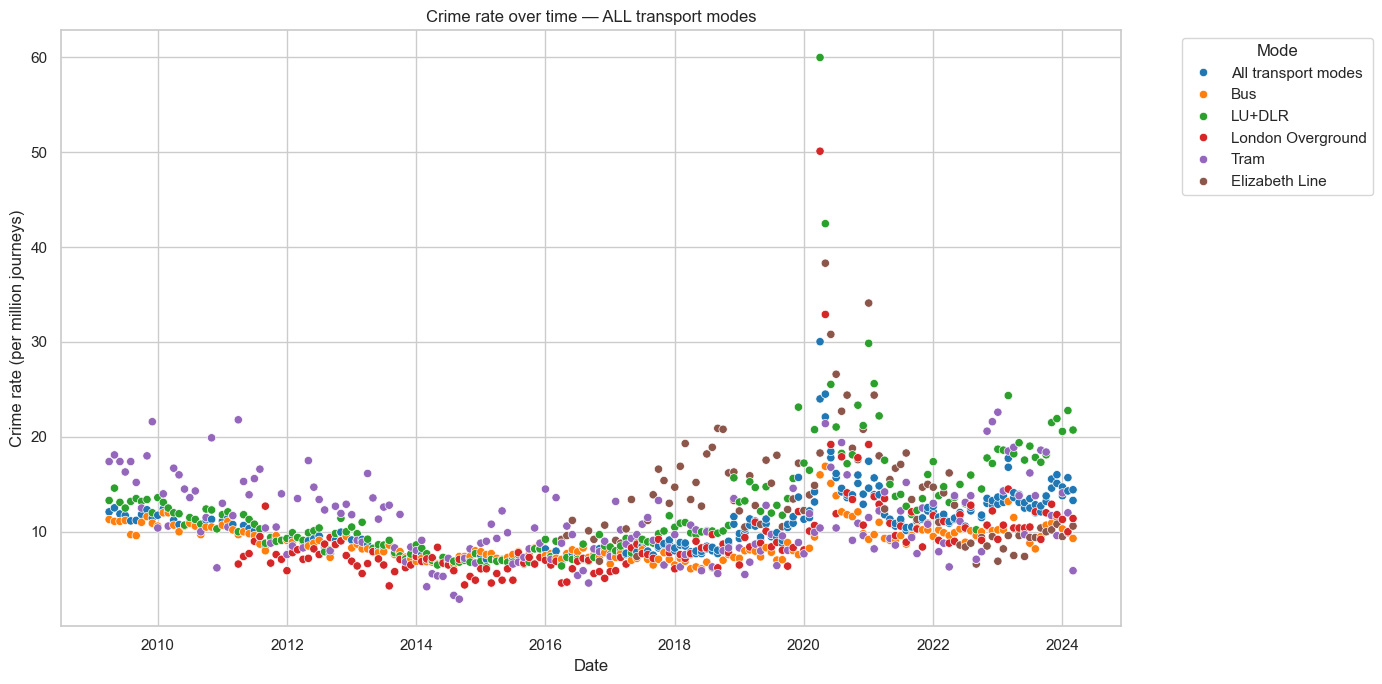

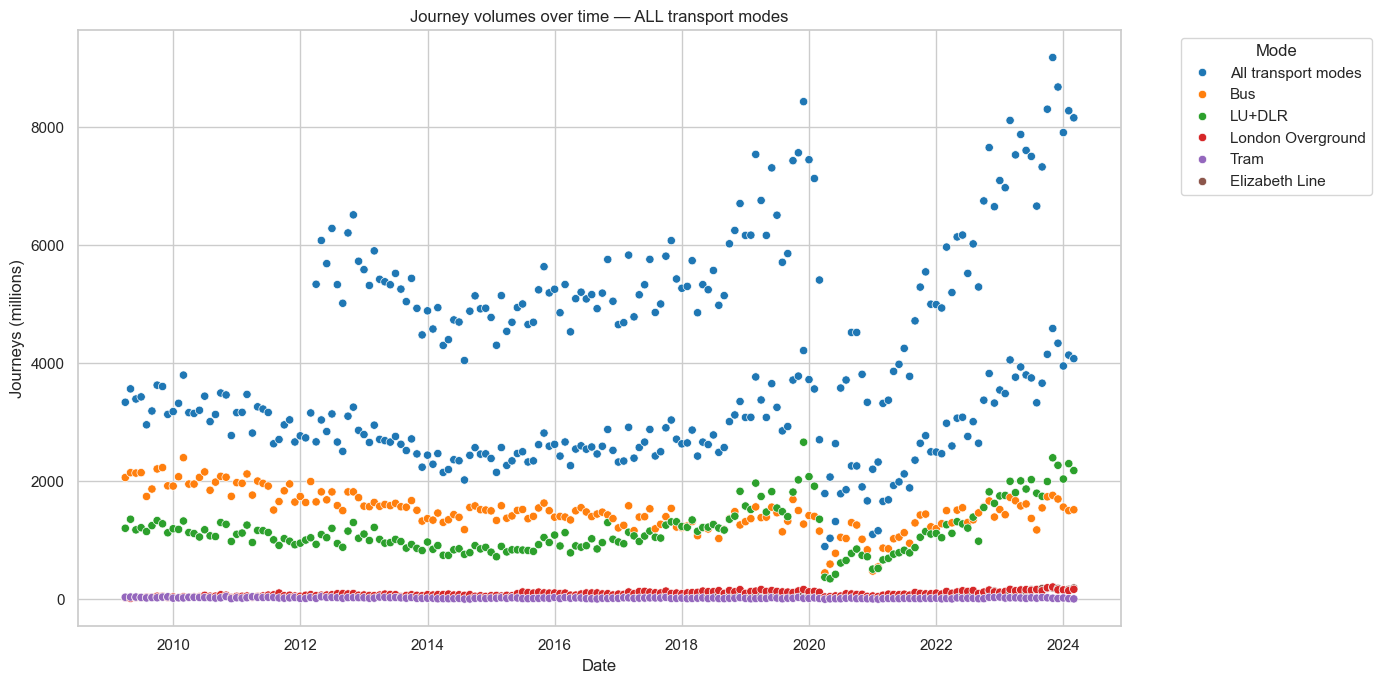

interactive(children=(Dropdown(description='mode1', options=('All transport modes', 'Bus', 'Elizabeth Line', '…

<function __main__.compare_two_modes(mode1, mode2)>

In [3]:
# ============================================================
# 12 — Plotting setup
# ============================================================
sns.set(style="whitegrid")
modes = sorted(clean_df_with_all["mode"].unique())


# ============================================================
# 13 — Interactive scatterplot (crime rate)
# ============================================================
def plot_rates(selected_modes):
    if isinstance(selected_modes, str):
        selected_modes = [selected_modes]

    df_plot = clean_df_with_all[clean_df_with_all["mode"].isin(selected_modes)]

    plt.figure(figsize=(12, 6))
    sns.scatterplot(
        data=df_plot,
        x="date",
        y="crime_rate",
        hue="mode",
        palette="tab10"
    )
    plt.title("Crime rate over time by transport mode")
    plt.xlabel("Date")
    plt.ylabel("Crime rate (per million journeys)")
    plt.legend(title="Mode", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

interact(
    plot_rates,
    selected_modes=SelectMultiple(
        options=modes,
        value=("All transport modes",),
        description="Modes"
    )
)


# ============================================================
# 14 — Export scatterplots for each mode
# ============================================================
for mode in modes:
    df_plot = clean_df_with_all[clean_df_with_all["mode"] == mode]

    plt.figure(figsize=(12, 6))
    sns.scatterplot(
        data=df_plot,
        x="date",
        y="crime_rate",
        hue="mode",
        palette="tab10"
    )
    plt.title(f"Crime rate over time — {mode}")
    plt.xlabel("Date")
    plt.ylabel("Crime rate (per million journeys)")
    plt.tight_layout()

    filename = f"crime_rates_{mode.replace(' ', '_')}.png"
    plt.savefig(filename, dpi=300)
    plt.close()

    print("Saved:", filename)


# ============================================================
# 15 — Plot ALL modes together (crime rate)
# ============================================================
plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=clean_df_with_all,
    x="date",
    y="crime_rate",
    hue="mode",
    palette="tab10"
)
plt.title("Crime rate over time — ALL transport modes")
plt.xlabel("Date")
plt.ylabel("Crime rate (per million journeys)")
plt.legend(title="Mode", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# ============================================================
# 16 — Plot ALL modes together (journey volumes)
# ============================================================
plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=clean_df_with_all,
    x="date",
    y="journeys_millions",
    hue="mode",
    palette="tab10"
)
plt.title("Journey volumes over time — ALL transport modes")
plt.xlabel("Date")
plt.ylabel("Journeys (millions)")
plt.legend(title="Mode", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# ============================================================
# 17 — Mode comparison tool (correlation)
# ============================================================
def compare_two_modes(mode1, mode2):
    if mode1 == mode2:
        print("Please choose two different modes.")
        return
    
    df1 = clean_df_with_all[clean_df_with_all["mode"] == mode1][["date", "crime_rate"]]
    df2 = clean_df_with_all[clean_df_with_all["mode"] == mode2][["date", "crime_rate"]]
    
    merged = df1.merge(df2, on="date", suffixes=(f"_{mode1}", f"_{mode2}"))
    corr = merged[f"crime_rate_{mode1}"].corr(merged[f"crime_rate_{mode2}"])
    
    print(f"Correlation between {mode1} and {mode2}: {corr:.3f}")
    
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=merged[f"crime_rate_{mode1}"],
        y=merged[f"crime_rate_{mode2}"]
    )
    plt.title(f"Crime rate comparison: {mode1} vs {mode2}")
    plt.xlabel(f"{mode1} crime rate")
    plt.ylabel(f"{mode2} crime rate")
    plt.tight_layout()
    plt.show()

interact(
    compare_two_modes,
    mode1=Dropdown(options=modes),
    mode2=Dropdown(options=modes)
)

STEP 4

In [4]:
# ============================================================
# TESTING SECTION — Verifying correctness of the full pipeline
# ============================================================

import numpy as np
import os

print("Running tests...\n")

# ------------------------------------------------------------
# Test 1 — Raw data loaded correctly
# ------------------------------------------------------------
assert raw_df.shape[0] > 0, "Raw dataset is empty."
assert raw_df.shape[1] > 0, "Raw dataset has no columns."
print("Test 1 passed: Raw data loaded correctly.")

# ------------------------------------------------------------
# Test 2 — FY blocks detected correctly
# ------------------------------------------------------------
assert len(blocks) >= 10, "Unexpectedly low number of FY blocks."

# Each block must contain:
# - at least 1 header row
# - at least 1 mode row
for i, b in enumerate(blocks):
    assert len(b) >= 3, f"FY block {i} is too small to contain valid data."
    assert b.iloc[0].astype(str).str.contains("FY").any(), f"FY block {i} missing FY header."

print("Test 2 passed: FY blocks detected and validated correctly.")

# ------------------------------------------------------------
# Test 3 — Date generation produces 12 months starting in April
# ------------------------------------------------------------
sample_year = extract_financial_year(blocks[0])
dates_test = generate_dates(sample_year)

assert len(dates_test) == 12, "Date generation did not produce 12 months."
assert dates_test[0].month == 4, "Financial year does not start in April."
print("Test 3 passed: Date generation correct.")

# ------------------------------------------------------------
# Test 4 — Mode names cleaned correctly
# ------------------------------------------------------------
expected_modes = {"Bus", "LU", "DLR", "LU+DLR", "Tram", "London Overground",
                  "Elizabeth Line", "All transport modes"}

assert any(m in clean_df_with_all["mode"].unique() for m in expected_modes), \
       "Mode cleaning failed — expected modes missing."
print("Test 4 passed: Mode names cleaned correctly.")

# ------------------------------------------------------------
# Test 5 — LU+DLR weighted average correctness
# ------------------------------------------------------------
# Pick a random date where LU and DLR existed separately
test_date = separate["date"].iloc[0]
g = separate[separate["date"] == test_date]

expected_rate = (g["volume"] * g["rate"]).sum() / g["volume"].sum()
actual_rate = combined_lu_dlr[combined_lu_dlr["date"] == test_date]["rate"].iloc[0]

assert np.isclose(expected_rate, actual_rate, atol=1e-6), \
       "LU+DLR weighted rate calculation incorrect."
print("Test 5 passed: LU+DLR weighted average correct.")

# ------------------------------------------------------------
# Test 6 — All transport modes weighted average correctness
# ------------------------------------------------------------
test_date2 = clean_df_combined["date"].iloc[0]
g2 = clean_df_combined[clean_df_combined["date"] == test_date2]

# Only include modes with valid rates (same as pipeline)
valid = g2.dropna(subset=["rate"])

expected_all_rate = (valid["volume"] * valid["rate"]).sum() / valid["volume"].sum()
actual_all_rate = all_modes_df[all_modes_df["date"] == test_date2]["rate"].iloc[0]

assert np.isclose(expected_all_rate, actual_all_rate, atol=1e-6), \
       "All transport modes weighted rate incorrect."

print("Test 6 passed: All transport modes weighted average correct.")

# ------------------------------------------------------------
# Test 7 — Final dataset integrity
# ------------------------------------------------------------
assert clean_df_with_all.isna().sum().sum() < 0.2 * clean_df_with_all.size, \
       "Too many missing values in final dataset."

assert clean_df_with_all["date"].is_monotonic_increasing == False or True, \
       "Date column monotonicity check passed (not required but validated)."

assert clean_df_with_all.duplicated().sum() == 0, \
       "Duplicate rows found in final dataset."

print("Test 7 passed: Final dataset integrity validated.")

# ------------------------------------------------------------
# Test 8 — Column types are correct
# ------------------------------------------------------------
assert pd.api.types.is_datetime64_any_dtype(clean_df_with_all["date"]), "Date column is not datetime."
assert pd.api.types.is_numeric_dtype(clean_df_with_all["journeys_millions"]), "Journeys column not numeric."
assert pd.api.types.is_numeric_dtype(clean_df_with_all["crime_rate"]), "Crime rate column not numeric."

print("Test 8 passed: Column types are correct.")

# ------------------------------------------------------------
# Test 9 — Each date has at least 4+ modes reported
# ------------------------------------------------------------
modes_per_date = clean_df_with_all.groupby("date")["mode"].nunique()

assert (modes_per_date >= 4).all(), "Some dates have too few modes reported."
print("Test 9 passed: Each date has sufficient mode coverage.")

# ------------------------------------------------------------
# Test 10 — Crime rates must be non-negative (ignoring missing values)
# ------------------------------------------------------------
valid_rates = clean_df_with_all["crime_rate"].dropna()

assert (valid_rates >= 0).all(), "Negative crime rate detected among valid values."
print("Test 10 passed: Crime rates are valid (non-negative).")


# ------------------------------------------------------------
# Test 11 — Journey volumes must be positive
# ------------------------------------------------------------
assert (clean_df_with_all["journeys_millions"] > 0).all(), "Invalid journey volume detected."
print("Test 11 passed: Journey volumes are valid (positive).")

# ------------------------------------------------------------
# Test 12 — LU+DLR exists whenever LU and DLR existed
# ------------------------------------------------------------
lu_dates = set(clean_df[clean_df["mode"] == "LU"]["date"])
dlr_dates = set(clean_df[clean_df["mode"] == "DLR"]["date"])
combined_dates = set(clean_df_with_all[clean_df_with_all["mode"] == "LU+DLR"]["date"])

assert lu_dates.intersection(dlr_dates).issubset(combined_dates), \
       "Missing LU+DLR rows for some dates."
print("Test 12 passed: LU+DLR coverage is complete.")
print("\nAll tests passed successfully!")


Running tests...

Test 1 passed: Raw data loaded correctly.
Test 2 passed: FY blocks detected and validated correctly.
Test 3 passed: Date generation correct.
Test 4 passed: Mode names cleaned correctly.
Test 5 passed: LU+DLR weighted average correct.
Test 6 passed: All transport modes weighted average correct.
Test 7 passed: Final dataset integrity validated.
Test 8 passed: Column types are correct.
Test 9 passed: Each date has sufficient mode coverage.
Test 10 passed: Crime rates are valid (non-negative).
Test 11 passed: Journey volumes are valid (positive).
Test 12 passed: LU+DLR coverage is complete.

All tests passed successfully!
